# DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
train = pd.read_csv('/kaggle/input/lish-moa/train_features.csv')
test = pd.read_csv('/kaggle/input/lish-moa/test_features.csv')
drug = pd.read_csv("/kaggle/input/lish-moa/train_drug.csv")

train_features.csv 
- Features g- signify gene expression data.
- Features c- signify cell viability data.
- cp_type indicates samples treated with a compound, trt_cp samples treated with the compounds.
- cp_vehicle or with a control perturbation (ctrl_vehicle); control perturbations have no MoAs.
- cp_time and cp_dose indicate treatment duration (24, 48, 72 hours) and dose (high or low).


In [3]:
print(train.shape, test.shape)
train.head()

(23814, 876) (3982, 876)


,sig_id,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
0,id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
1,id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
2,id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931
3,id_0015fd391,trt_cp,48,D1,-0.5138,-0.2491,-0.2656,0.5288,4.0620,-0.8095,...,-2.0990,-0.6441,-5.6300,-1.3780,-0.8632,-1.2880,-1.6210,-0.8784,-0.3876,-0.8154
4,id_001626bd3,trt_cp,72,D2,-0.3254,-0.4009,0.9700,0.6919,1.4180,-0.8244,...,0.0042,0.0048,0.6670,1.0690,0.5523,-0.3031,0.1094,0.2885,-0.3786,0.7125


# Train Drug

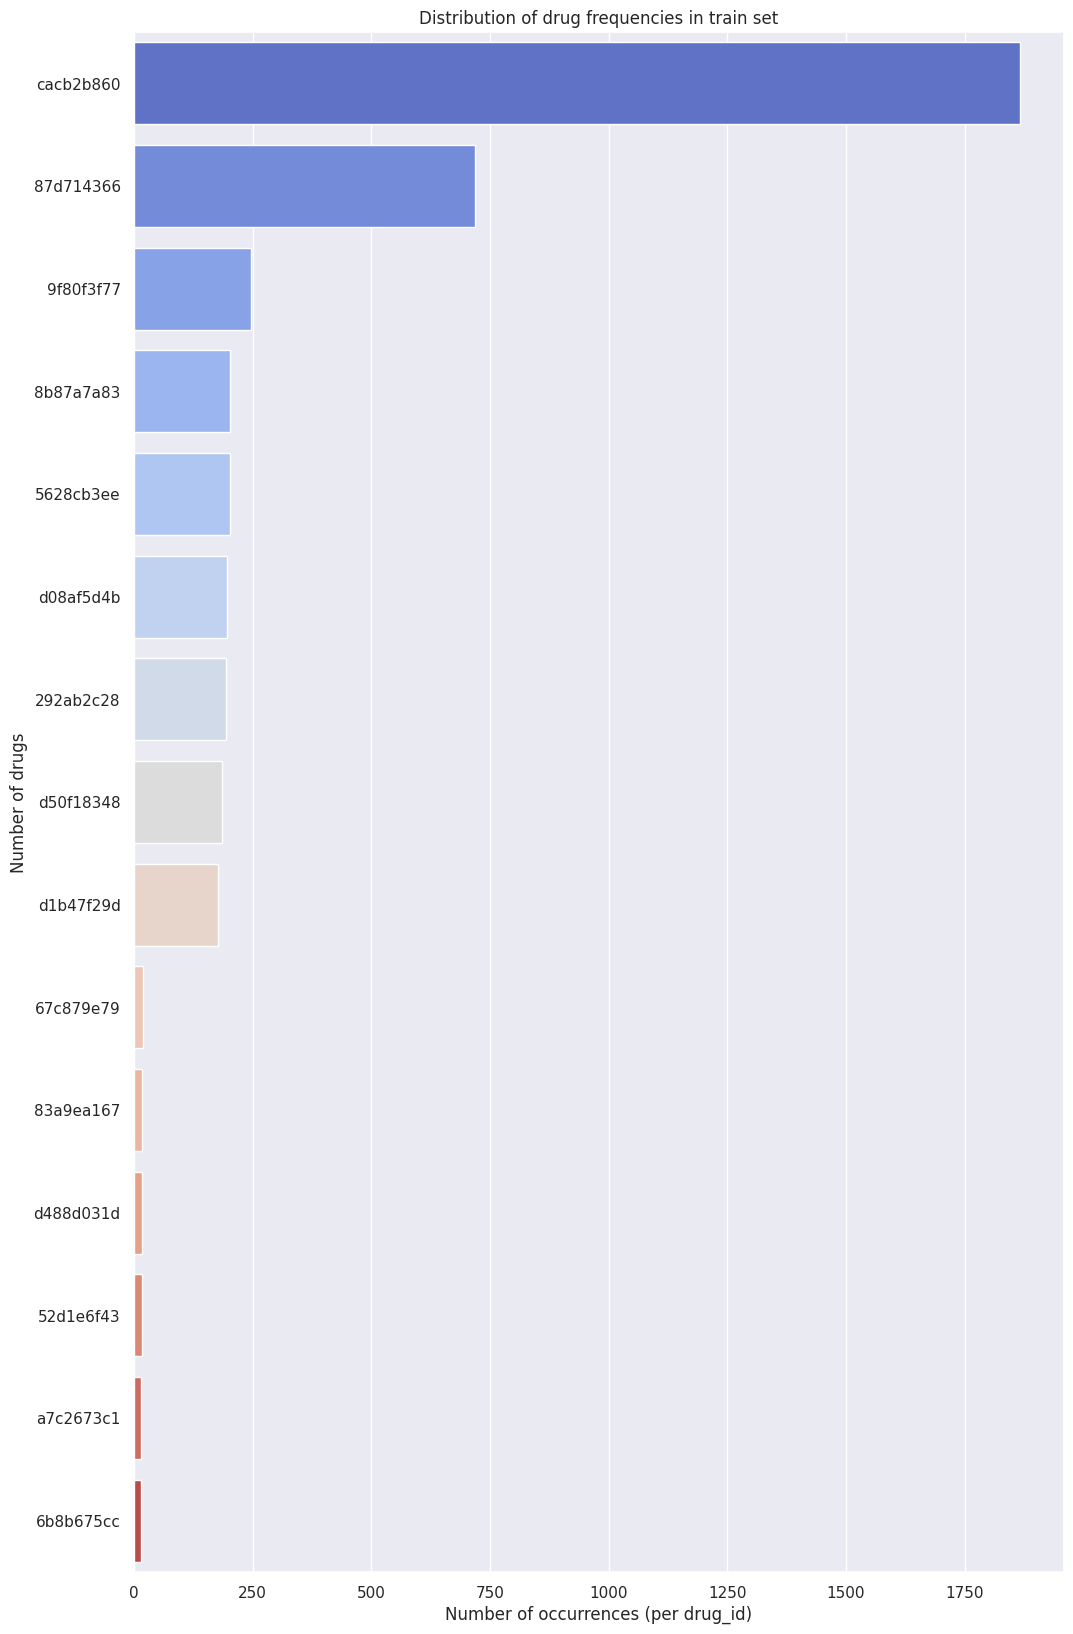

In [4]:
drug_counts = drug['drug_id'].value_counts().reset_index()
drug_counts_30 = drug_counts.head(15)
colors = sns.color_palette("coolwarm", len(drug_counts_30))

plt.figure(figsize=(12,20))
sns.set_theme(style="darkgrid", palette="deep")
sns.barplot(data=drug_counts_30, y="drug_id", x="count", orient="h", palette=colors)
plt.title("Distribution of drug frequencies in train set")
plt.xlabel("Number of occurrences (per drug_id)")
plt.ylabel("Number of drugs")
plt.show()

# Features

## Check categorical features: cp_type, cp_time, cp_dose.

['trt_cp' 'ctl_vehicle']


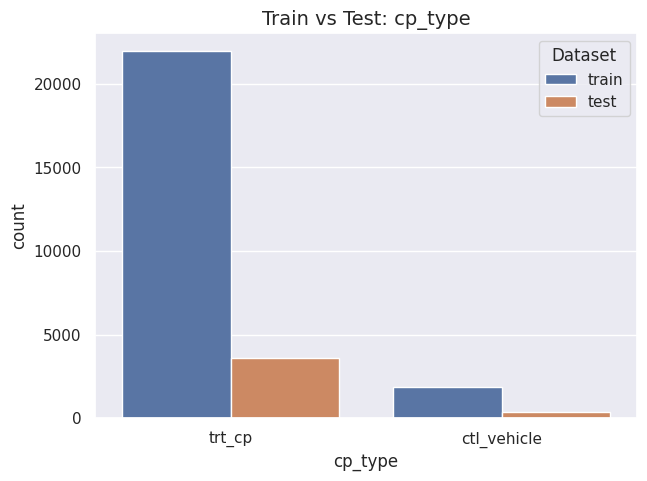

In [5]:
print(train['cp_type'].unique())

train['dataset'] = 'train'
test['dataset'] = 'test'

test_train_data = pd.concat([train, test], axis=0)


plt.figure(figsize=(7,5))
plt.title("Train vs Test: cp_type", fontsize=14)
sns.countplot(data=test_train_data, x="cp_type", hue="dataset")
plt.xlabel("cp_type")
plt.legend(title="Dataset")


[24 72 48]


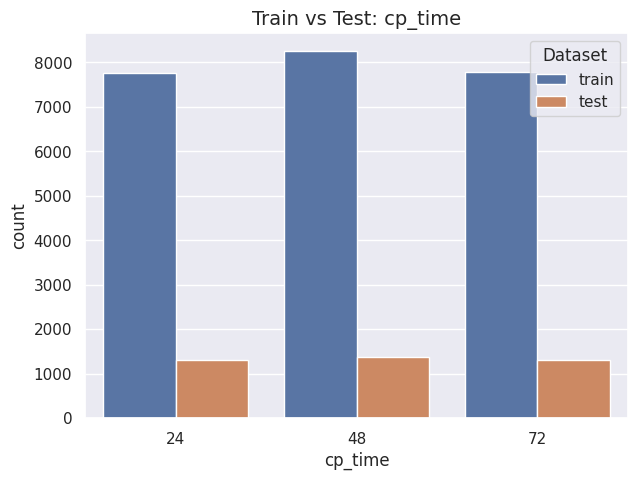

In [6]:
print(train['cp_time'].unique())

plt.figure(figsize=(7,5))
plt.title("Train vs Test: cp_time", fontsize=14)
sns.countplot(data=test_train_data, x="cp_time", hue="dataset")
plt.xlabel("cp_time")
plt.legend(title="Dataset")


['D1' 'D2']


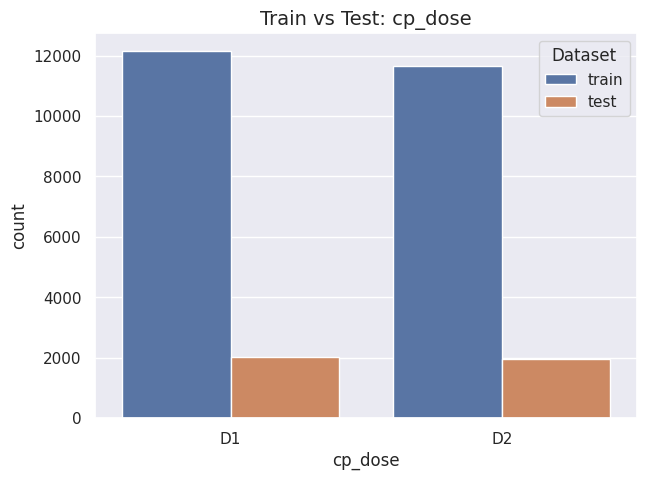

In [7]:
print(train['cp_dose'].unique())

plt.figure(figsize=(7,5))
plt.title("Train vs Test: cp_dose", fontsize=14)
sns.countplot(data=test_train_data, x="cp_dose", hue="dataset")
plt.xlabel("cp_dose")
plt.legend(title="Dataset")

## Gene and cell features distribution

In [8]:
train_columns = train.columns.to_list()

g_cols = [i for i in train_columns if i.startswith('g-')]
c_cols = [i for i in train_columns if i.startswith('c-')]
print(len(g_cols), len(c_cols))

772 100


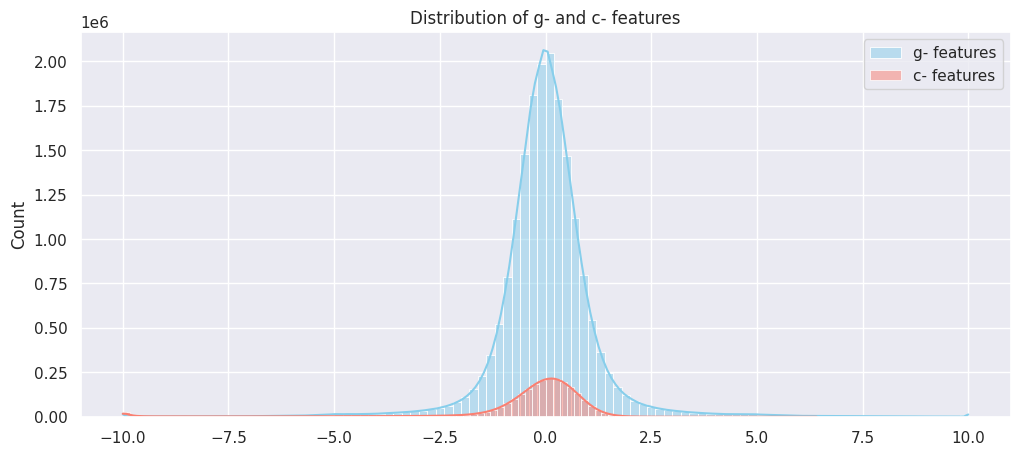

In [9]:
plt.figure(figsize=(12,5))
sns.histplot(train[g_cols].values.flatten(), bins=100, color="skyblue", label="g- features", kde=True)
sns.histplot(train[c_cols].values.flatten(), bins=100, color="salmon", label="c- features", kde=True)
plt.legend()
plt.title("Distribution of g- and c- features")
plt.show()

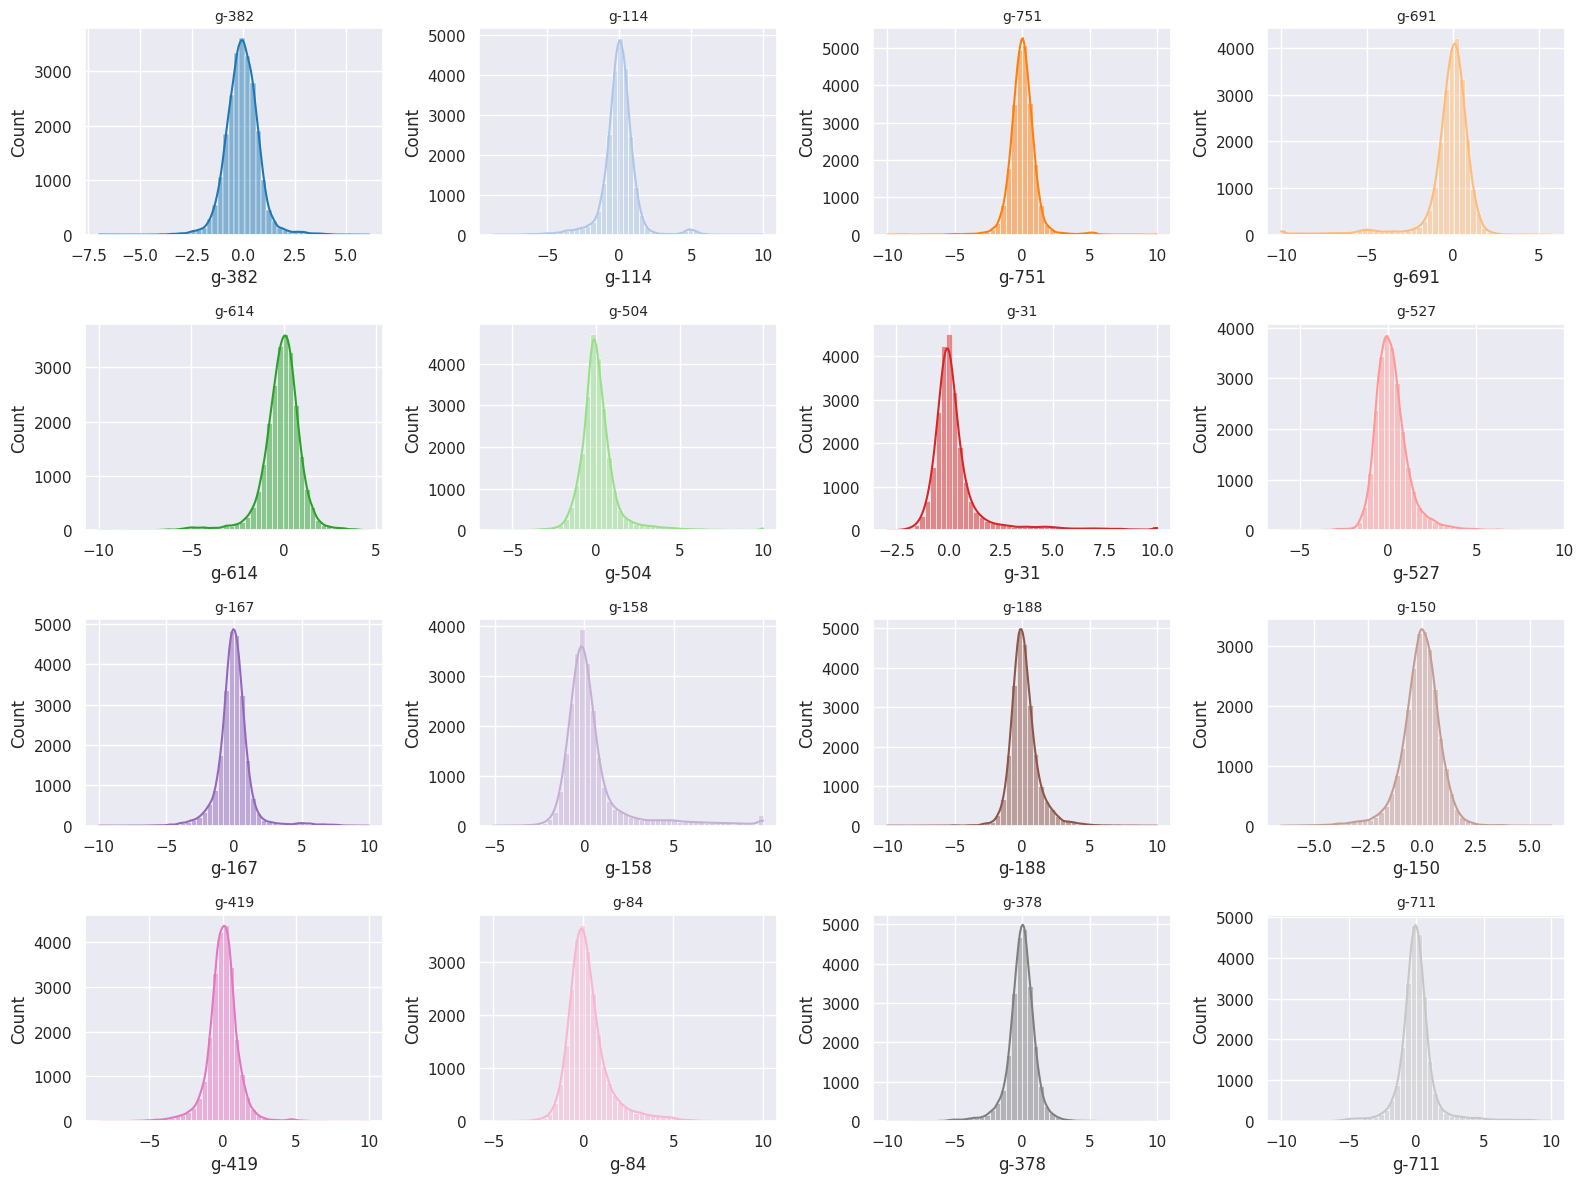

In [10]:
sample_genes = np.random.choice(g_cols, 16, replace=False)
colors = sns.color_palette("tab20", 16)

plt.figure(figsize=(16,12))
for i, (g, col) in enumerate(zip(sample_genes, colors), 1):
    plt.subplot(4,4,i)
    sns.histplot(train[g], bins=50, kde=True, color=col)
    plt.title(g, fontsize=10)
    plt.tight_layout()
plt.show()

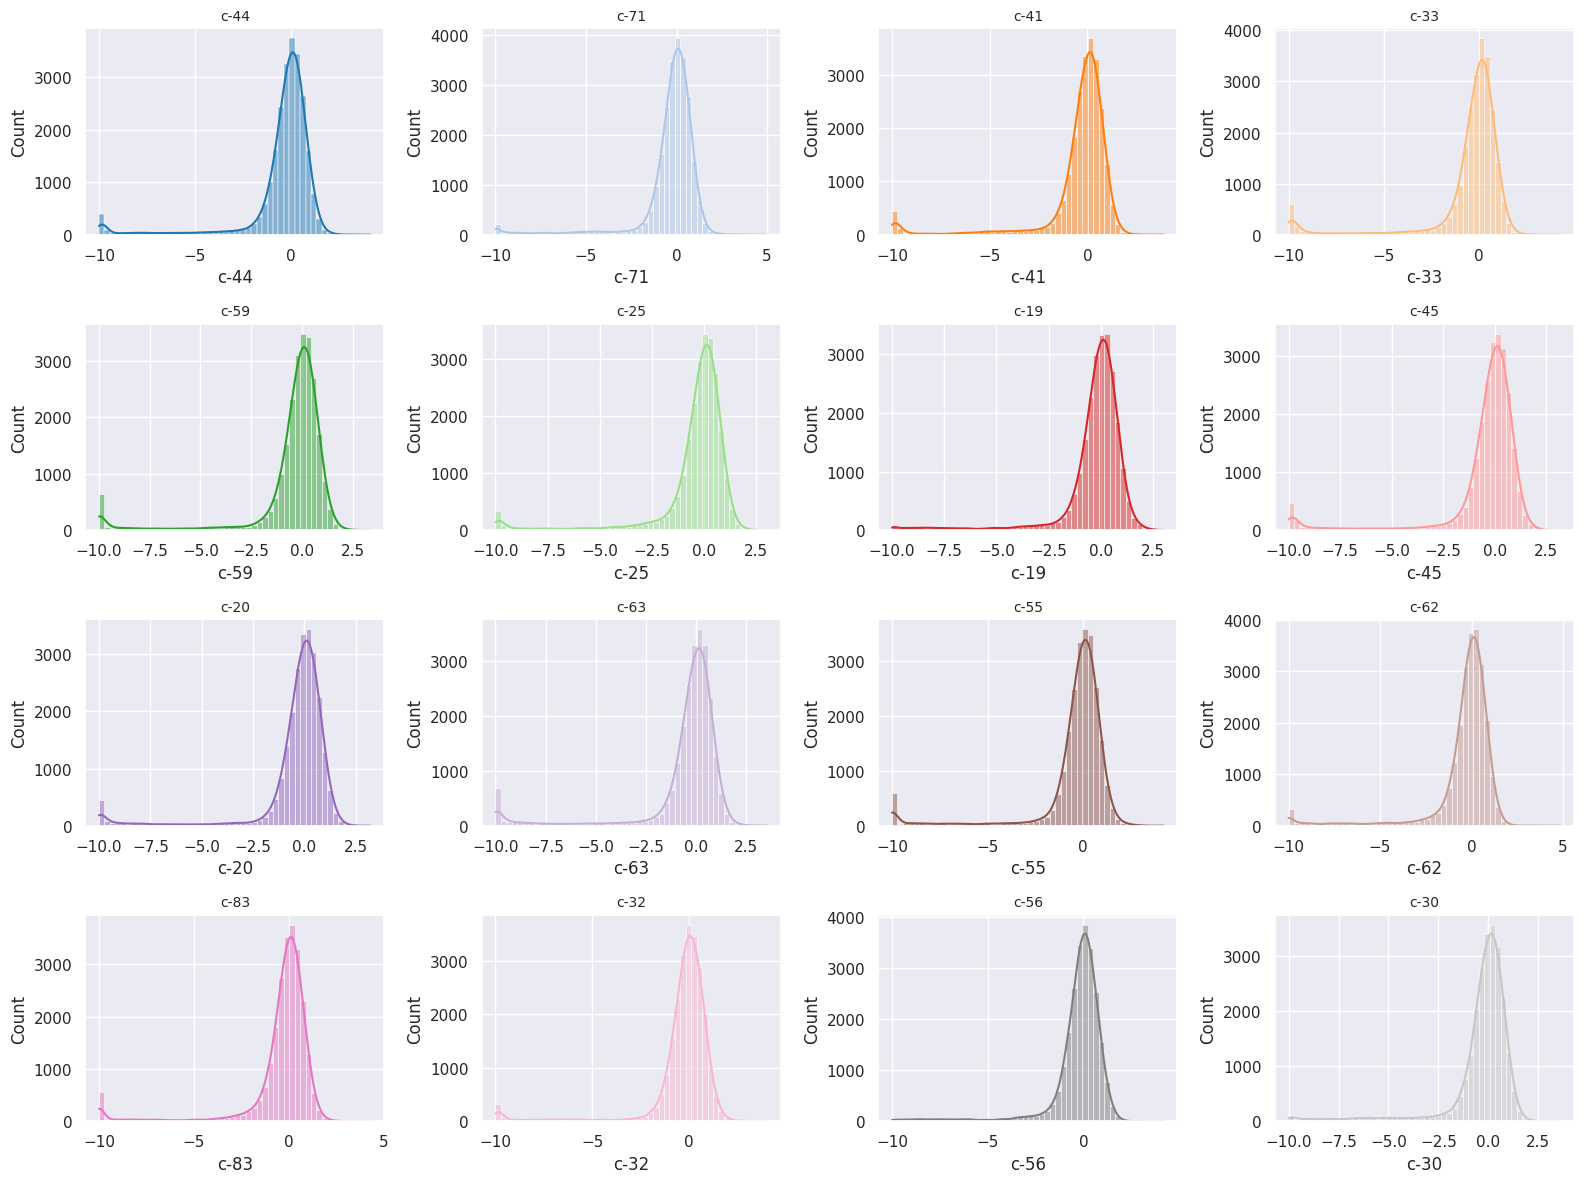

In [11]:
sample_cells = np.random.choice(c_cols, 16, replace=False)
colors = sns.color_palette("tab20", 16)

plt.figure(figsize=(16,12))
for i, (c, col) in enumerate(zip(sample_cells, colors), 1):
    plt.subplot(4,4,i)
    sns.histplot(train[c], bins=50, kde=True, color=col)
    plt.title(c, fontsize=10)
    plt.tight_layout()
plt.show()

## Corelation gene/cells

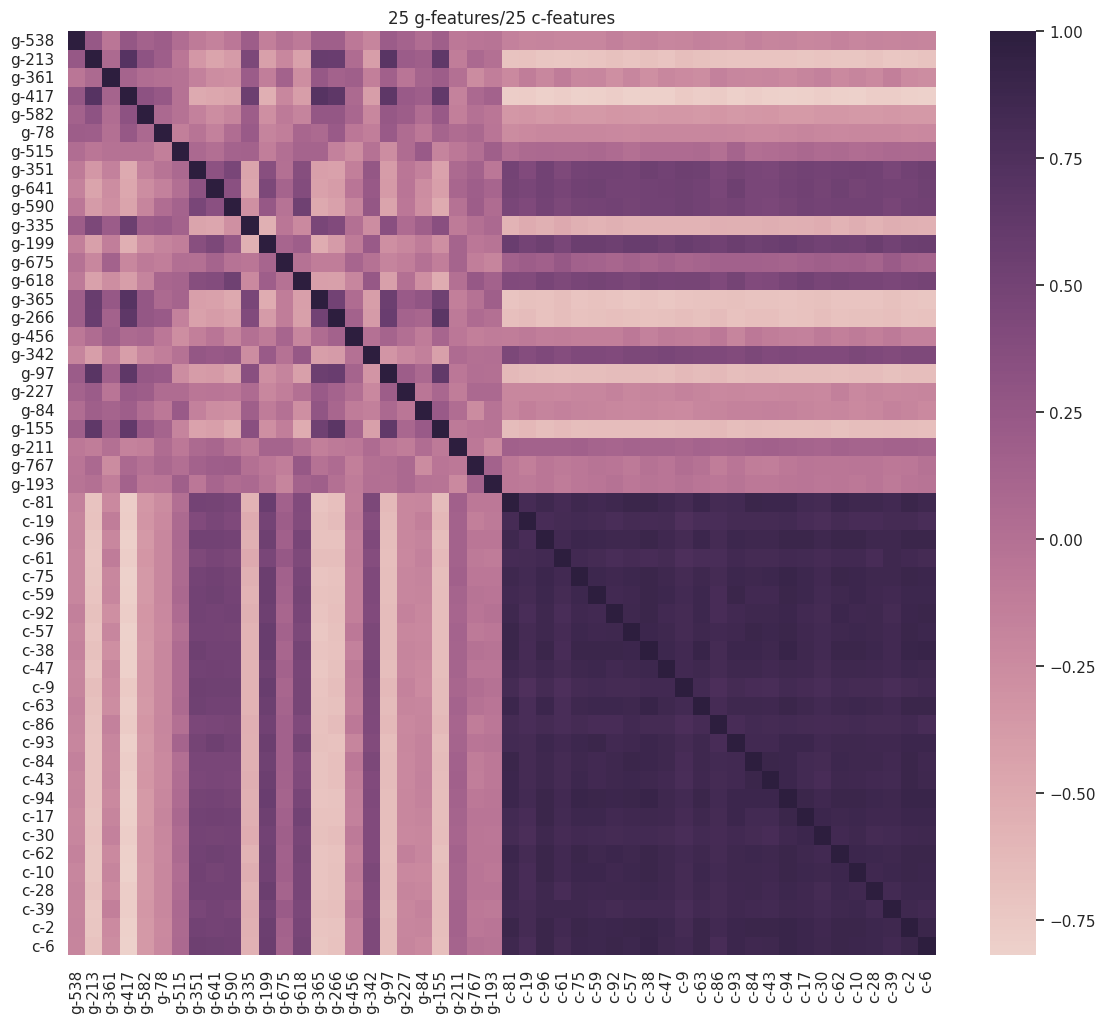

In [12]:
np.random.seed(42)
sample_g = np.random.choice(g_cols, 25, replace=False)
sample_c = np.random.choice(c_cols, 25, replace=False)
sample_feats = list(sample_g) + list(sample_c)

corr = train[sample_feats].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap=sns.cubehelix_palette(as_cmap=True))
plt.title("25 g-features/25 c-features")
plt.show()

Correlation analysis shows that c-features are highly correlated with each other, while g-features are more diverse with only small clusters of correlations. There is little direct correlation between g- and c-features, suggesting they provide complementary information.

Text(0.5, 1.0, '60 random g-features')

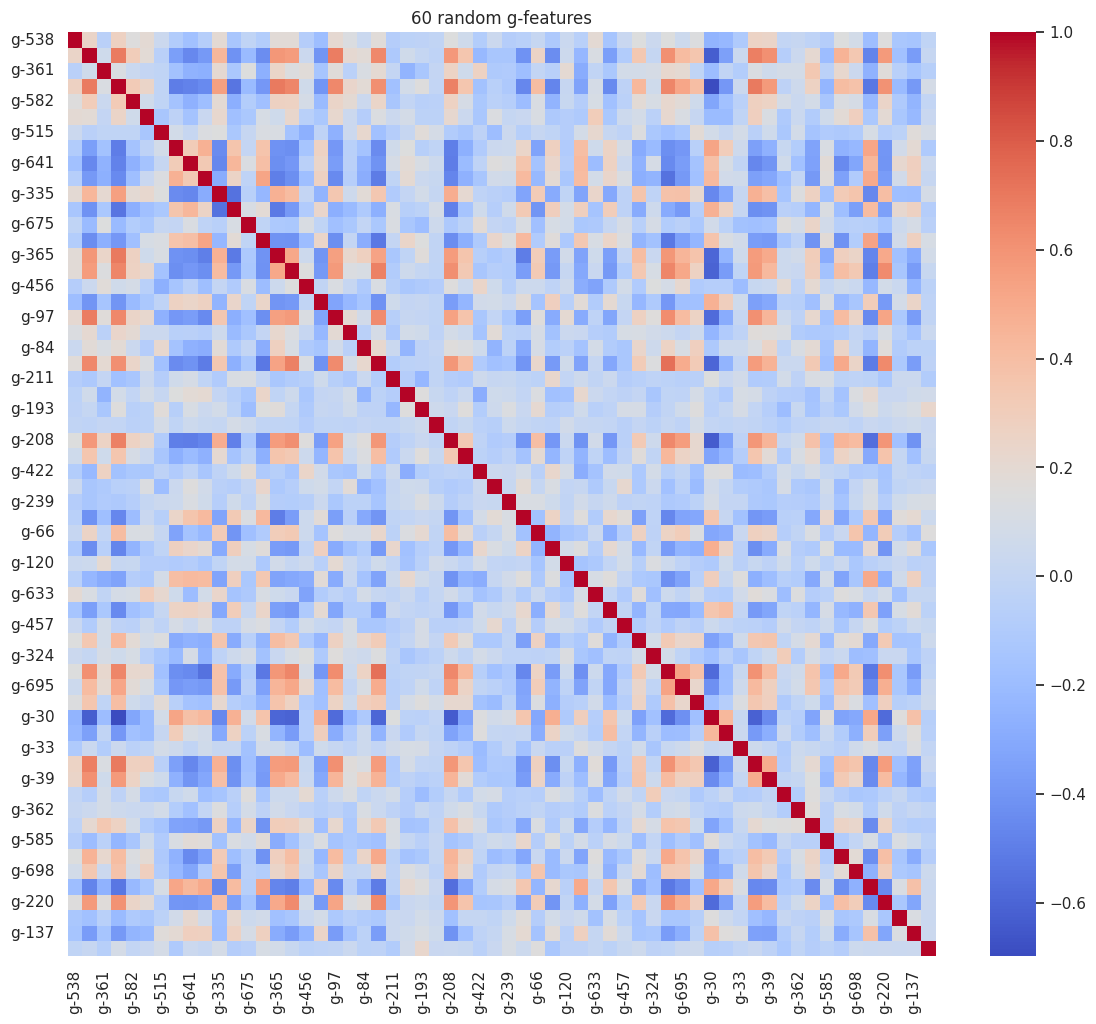

In [13]:
np.random.seed(42)
sample_g = np.random.choice(g_cols, 60, replace=False)

corr = train[sample_g].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("60 random g-features")

Text(0.5, 1.0, '60 random c-features')

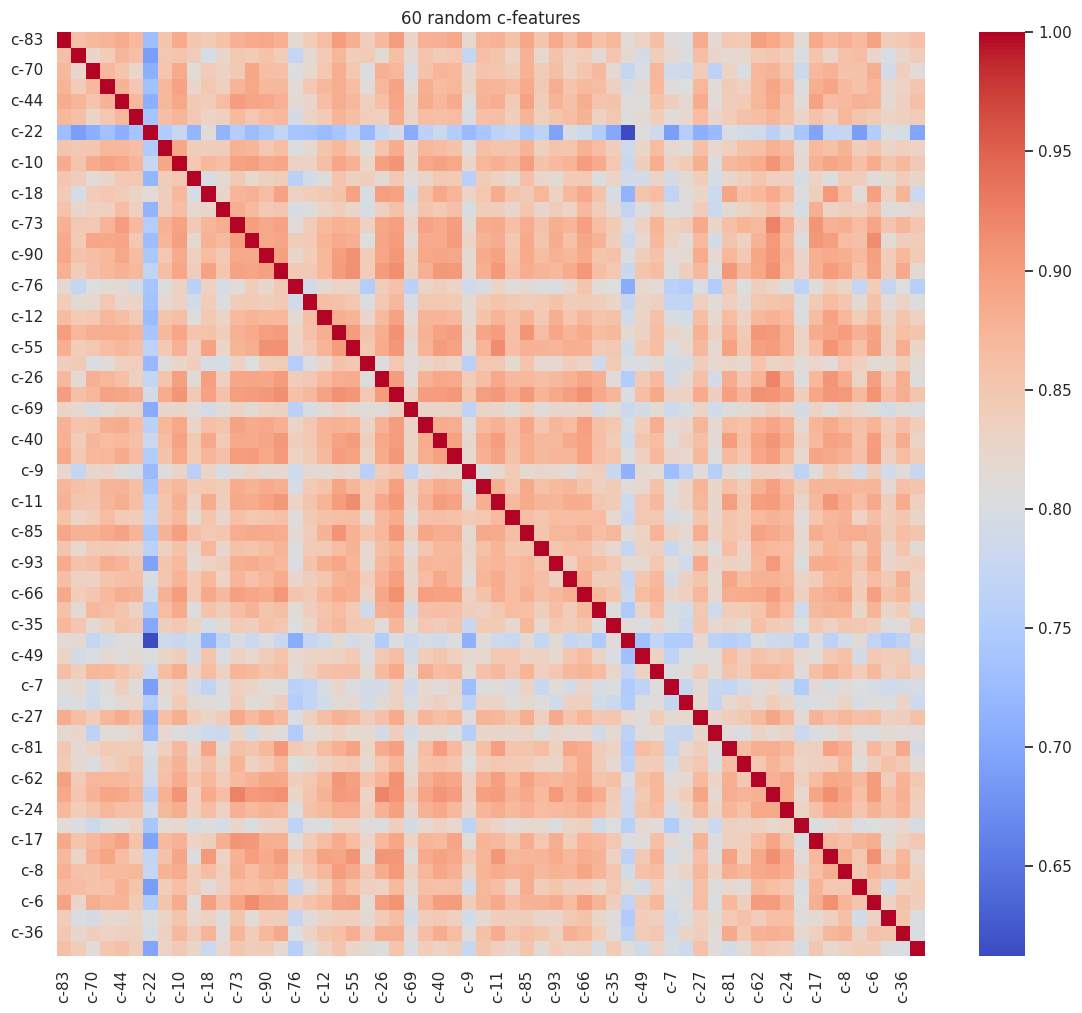

In [14]:
np.random.seed(42)
sample_g = np.random.choice(c_cols, 60, replace=False)

corr = train[sample_g].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("60 random c-features")

## PCA

У нас дані дуже сильно корелюють, тому ми зможемо застосувати PCA

In [15]:
scaler_g = StandardScaler()
X_g = scaler_g.fit_transform(train[g_cols])


pca_g = PCA(n_components=2)
X_g_pca = pca_g.fit_transform(X_g)

# Target

In [16]:
train_targets = pd.read_csv('/kaggle/input/lish-moa/train_targets_scored.csv')
print(train_targets.isna().sum().sum())
train_targets.head()

0


,sig_id,5-alpha_reductase_inhibitor,11-beta-hsd1_inhibitor,acat_inhibitor,acetylcholine_receptor_agonist,acetylcholine_receptor_antagonist,acetylcholinesterase_inhibitor,adenosine_receptor_agonist,adenosine_receptor_antagonist,adenylyl_cyclase_activator,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
0,id_000644bb2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,id_000779bfc,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,id_000a6266a,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,id_0015fd391,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,id_001626bd3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Text(0, 0.5, 'Target')

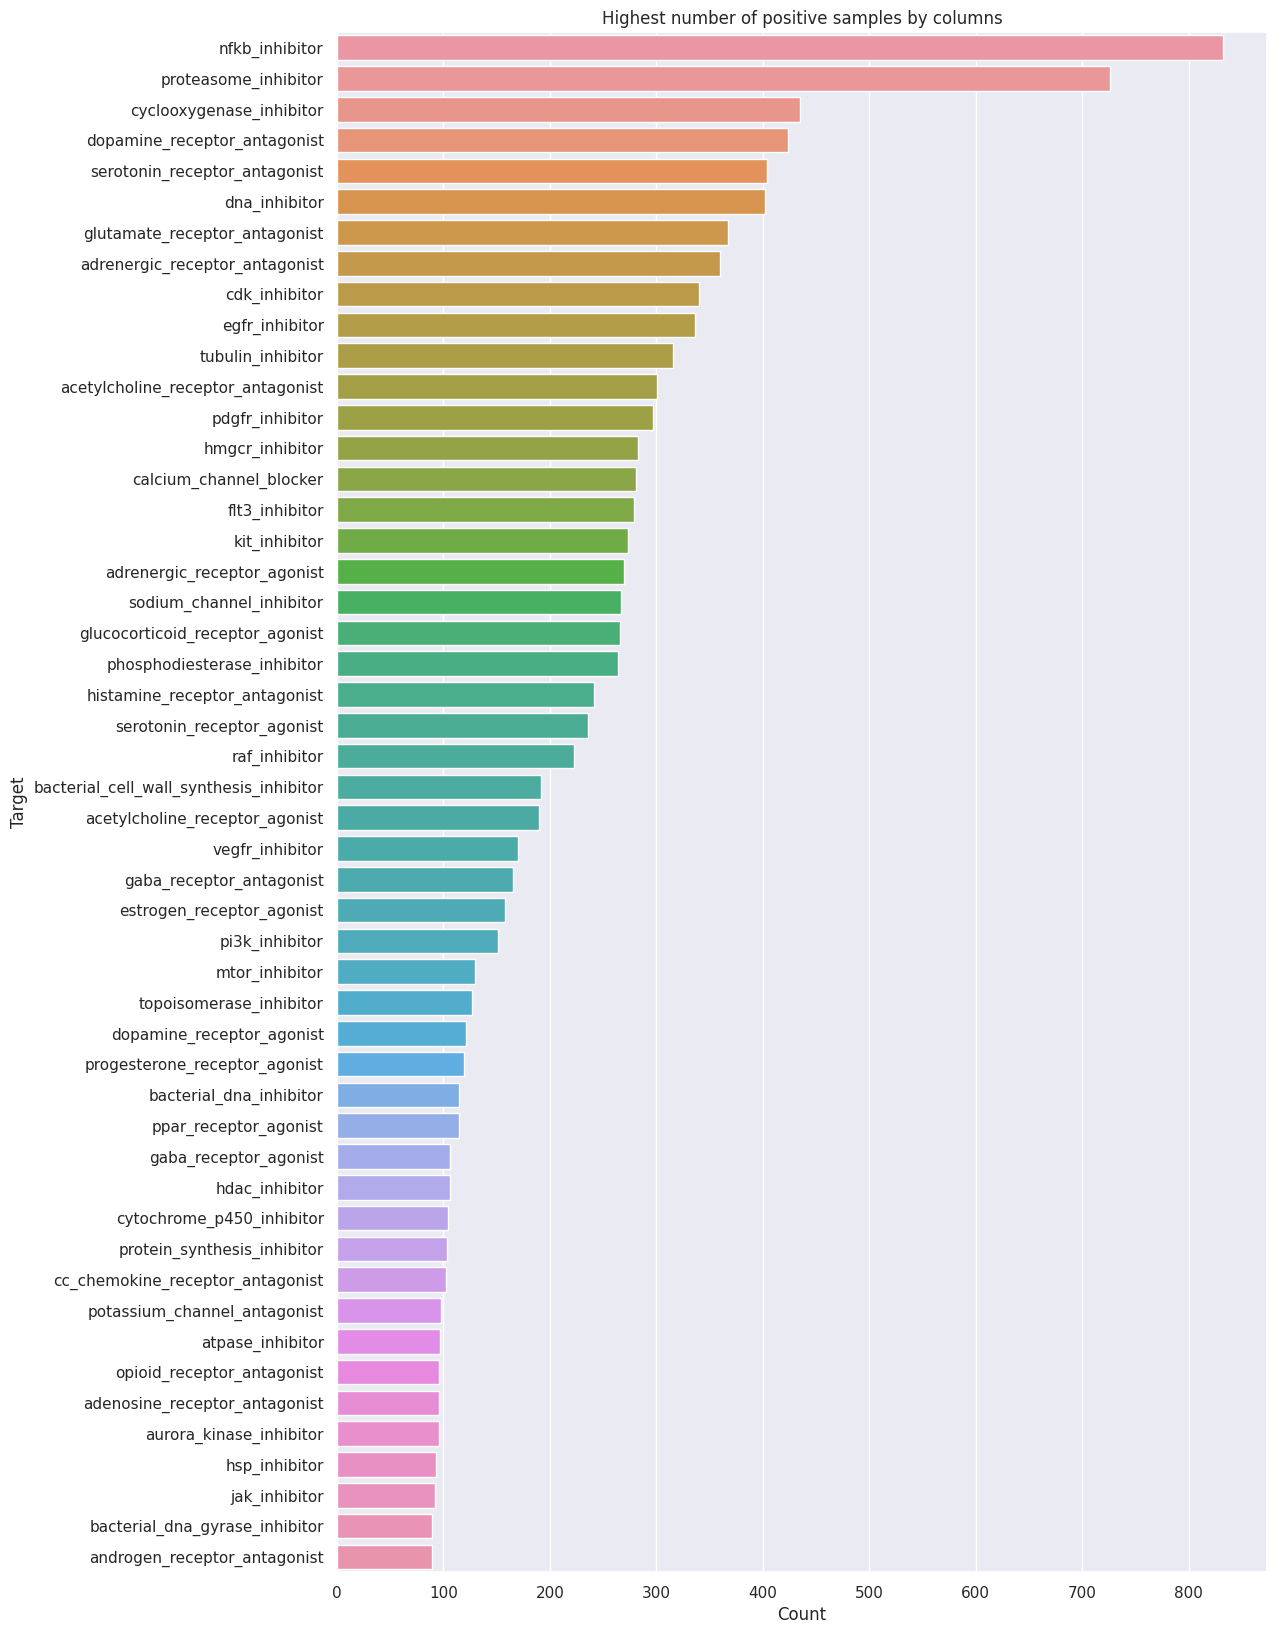

In [17]:
x = train_targets.drop(['sig_id'], axis=1).sum().sort_values(ascending=False).reset_index()
x.columns = ['target', 'count']

x_top50 = x.head(50)

plt.figure(figsize=(12, 20))
sns.barplot(data=x_top50, y="target", x="count", orient="h")
plt.title("Highest number of positive samples by columns")
plt.xlabel("Count")
plt.ylabel("Target")

Text(0, 0.5, 'Target')

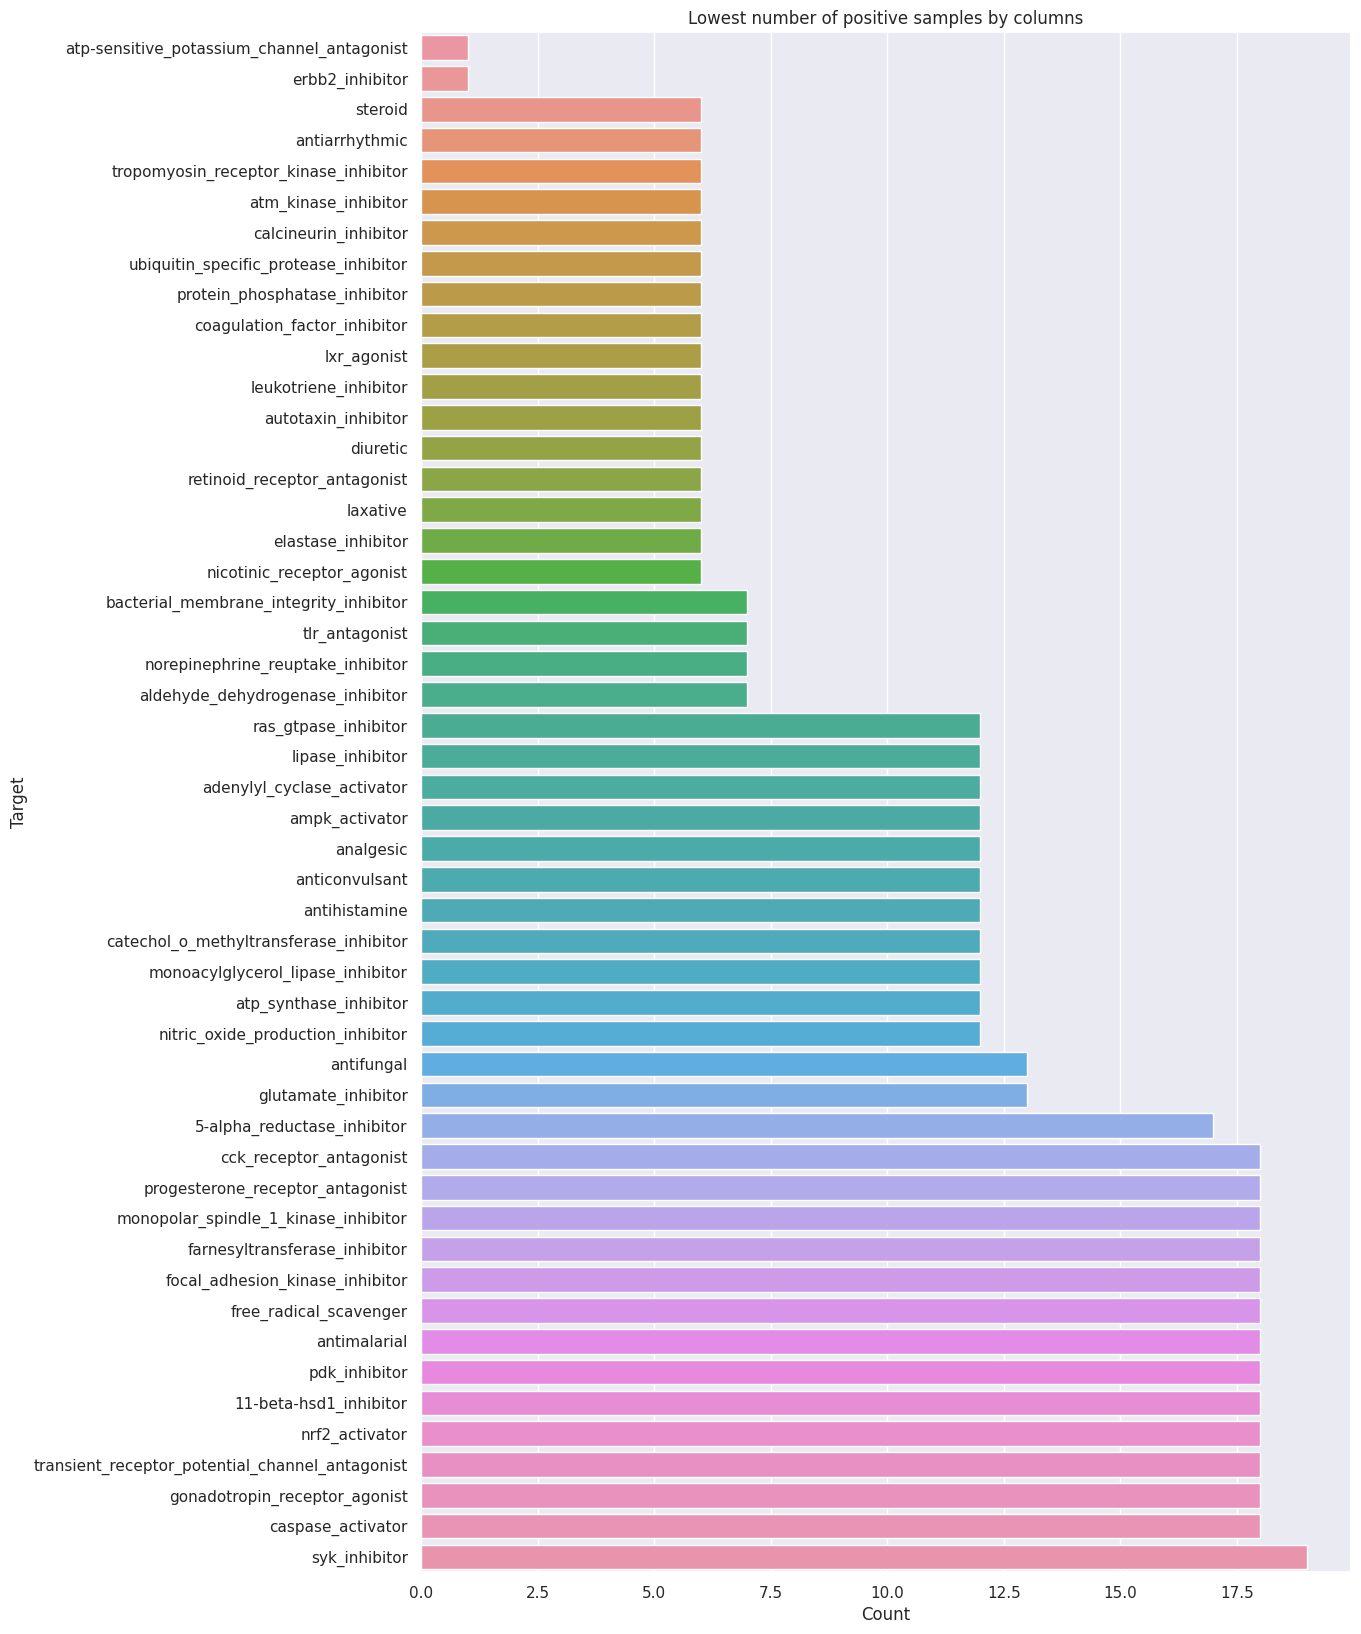

In [18]:
x_top50_asc = x.sort_values(ascending=True, by='count').head(50)

plt.figure(figsize=(12, 20))
sns.barplot(data=x_top50_asc, y="target", x="count", orient="h")
plt.title("Lowest number of positive samples by columns")
plt.xlabel("Count")
plt.ylabel("Target")

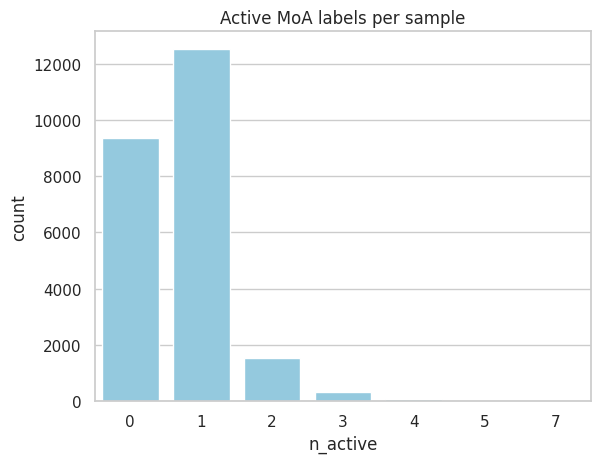

In [19]:
data = train_targets.drop(['sig_id'], axis=1)
data['n_active'] = data.sum(axis=1) 
data

freq_table = data['n_active'].value_counts().sort_index().reset_index()

sns.set_theme(style="whitegrid", palette="pastel")
sns.barplot(data=freq_table, x='n_active', y='count', color="skyblue")
plt.title("Active MoA labels per sample")
plt.xlabel("n_active")
plt.ylabel("count")
plt.show()

# Train & Targets correlations

Можливо зроблю